In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc_context
import matplotlib.patheffects as path_effects
from matplotlib.collections import LineCollection
from matplotlib import patches
from matplotlib.cm import ScalarMappable
import sunpy
import sunpy.map
from sunpy.coordinates import propagate_with_solar_surface
from sunpy.coordinates.spice import get_rotation_matrix
import astropy
from astropy.coordinates import SkyCoord
import astropy.units as u
import astropy.constants as const
from astropy.io import fits, ascii
from astropy.time import Time
from astropy.convolution import convolve, Gaussian2DKernel
from astropy.wcs import WCS
from astropy.visualization import ImageNormalize, AsinhStretch
from streamtracer import StreamTracer, VectorGrid
from extrapolater import PotentialField
from helpers import from_local
from ndcube.wcs.tools import unwrap_wcs_to_fitswcs
from sun_blinker import SunBlinker, ImageBlinker

import h5py 
import dask.array as da 
from ndcube import NDCube
from fancy_colorbar import plot_colorbar
import os 
os.environ["SPICE_KERNEL_PATH"] = "/cluster/home/zhuyin/scripts/spice_kernel/"
from mag_reproject import hgs_local_to_heeq_cart

from copy import deepcopy

import sys
sys.path.append("/cluster/home/zhuyin/scripts/MHSXtraPy/")

from mhsxtrapy.b3d import WhichSolution
from mhsxtrapy.examples import multipole
from mhsxtrapy.field2d import Field2dData, FluxBalanceState, check_fluxbalance
from mhsxtrapy.field3d import calculate_magfield, Field3dData
from mhsxtrapy.plotting.vis import (
    plot_ddensity_xy,
    plot_ddensity_z,
    plot_dpressure_xy,
    plot_dpressure_z,
    plot_magnetogram_2D,
    plot_magnetogram_3D,
)

import pyvista as pv

In [3]:
file_Hbeta_pr = h5py.File("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_pr.hdf5")
Hbeta_pr_set = file_Hbeta_pr["vbi_img"]
Hbeta_pr_da = da.from_array(Hbeta_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Hbeta_date_obs = Time(ascii.read("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_date_avg.txt")["DATE-AVG"])

In [2]:
dkist_vbi_target_header = fits.getheader("../../data/pid_1_123_aux/plot_ready/dkist_target_wcs_header_before_crop.fits",
                                        ignore_missing_simple=True)

dkist_vbi_target_data = np.zeros((4096,4096))

dkist_vbi_target_cube = NDCube(dkist_vbi_target_data,WCS(dkist_vbi_target_header, naxis=2))
dkist_vbi_target_cube_crop = dkist_vbi_target_cube[128:-128,128:-128]
dkist_vbi_target_cube_crop_rebin = dkist_vbi_target_cube_crop.rebin((8,8))

2026-04-29 13:53:58 - synthesizAR - WARNING: File may have been truncated: actual file length (25920) is smaller than the expected size (67135680)
Set MJD-BEG to 59876.791095 from DATE-BEG.
Set MJD-AVG to 59876.791095 from DATE-AVG.
Set MJD-END to 59876.791095 from DATE-END'. [astropy.wcs.wcs]
2026-04-29 13:53:58 - synthesizAR - WARNING: FITSFixedWarning: 'datfix' made the change 'Set MJDREF to 59876.791095 from DATEREF.
Set MJD-BEG to 59876.791095 from DATE-BEG.
Set MJD-AVG to 59876.791095 from DATE-AVG.
Set MJD-END to 59876.791095 from DATE-END'.
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
2026-04-29 13:53:58 - synthesizAR - WARNING: FITSFixedWarning: 'obsfix' made the change 'Set OBSGEO-L to  -156.256400 from OBSGEO-[XYZ].
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'.


In [4]:
def get_field_3d(data3d_path, xlisce=slice(400, 610), yslice=slice(200, 400), zslice=slice(3,7)):
    data3d = Field3dData.load(data3d_path)

    nx, ny, nz, nf = 960, 536, 536, 536
    # xmin, xmax, ymin, ymax, zmin, zmax = 0.0, 1.0, 0.0, 1.0, 0.0, 1.0

    pixelsize_x = 0.23712652199468398
    pixelsize_y = pixelsize_x
    pixelsize_z = pixelsize_x

    # x_arr = np.linspace(xmin, xmax, nx, dtype=np.float64)
    # y_arr = np.linspace(ymin, ymax, ny, dtype=np.float64)
    # z_arr = np.linspace(zmin, zmax, nz, dtype=np.float64)
    x_arr = np.arange(nx) * pixelsize_x
    y_arr = np.arange(ny) * pixelsize_y
    z_arr = np.arange(nz) * pixelsize_z

    bx_extra = data3d.field[:,:,:,1]
    by_extra = data3d.field[:,:,:,0]
    bz_extra = data3d.field[:,:,:,2]

    bx_extra = bx_extra[ny:ny*2, nx:nx*2,:]
    by_extra = by_extra[ny:ny*2, nx:nx*2,:]
    bz_extra = bz_extra[ny:ny*2, nx:nx*2,:]

    bx_sliced = bx_extra[yslice, xlisce, zslice].transpose(1,0,2)
    by_sliced = by_extra[yslice, xlisce, zslice].transpose(1,0,2)
    bz_sliced = bz_extra[yslice, xlisce, zslice].transpose(1,0,2)

    del data3d, bx_extra, by_extra, bz_extra

    return bx_sliced, by_sliced, bz_sliced

In [5]:
bx_v2_sliced, by_v2_sliced, bz_v2_sliced = get_field_3d(
    "../../data/pid_1_123_aux/MHSXtra_results/SOTSP_test_full_v2/",
    xlisce=slice(400, 610), yslice=slice(200, 400), zslice=slice(3,7))    

In [6]:
np.savez("../../data/pid_1_123_aux/MHSXtra_results/SOTSP_test_full_v2_slice/SOTSP_test_full_v2_slice.npz",
    bx_v2_sliced=bx_v2_sliced, by_v2_sliced=by_v2_sliced, bz_v2_sliced=bz_v2_sliced)

In [7]:
sotsp_br_map = sunpy.map.Map("../../data/pid_1_123_aux/SOTSP/sotsp_bz_hgs_cea_fullfov.fits")

In [10]:
sotsp_br_map_crop = sotsp_br_map.submap(
    bottom_left=(400, 200)*u.pix,
    top_right=(610-1, 400-1)*u.pix
)

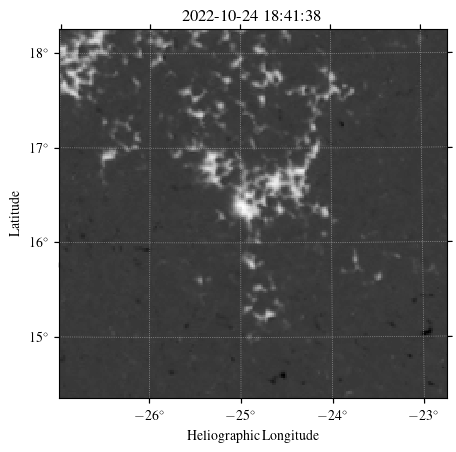

In [11]:
sotsp_br_map_crop.plot()

In [12]:
sotsp_br_map_crop_center_lon = sotsp_br_map_crop.center.lon.to_value(u.deg)
sotsp_br_map_crop_center_lat = sotsp_br_map_crop.center.lat.to_value(u.deg)

In [13]:
bx_heeq, by_heeq, bz_heeq = hgs_local_to_heeq_cart(
    bx_v2_sliced, by_v2_sliced, bz_v2_sliced,
    sotsp_br_map_crop_center_lon, sotsp_br_map_crop_center_lat
)

In [8]:
rotation_matrix = get_rotation_matrix("SUN_EARTH_CEQU", "EARTH_SOLAR_MHP", sotsp_br_map.date.isot)

In [14]:
b_heeq_stack = np.stack([bx_heeq, by_heeq, bz_heeq], axis=-1)
b_mhp = b_heeq_stack @ rotation_matrix.T
b_hpln, b_hplt, b_hpr = -b_mhp[..., 0], b_mhp[...,1], b_mhp[...,2]

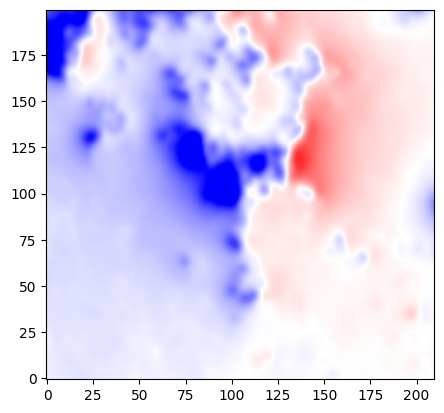

In [31]:
with plt.style.context("default"):
    fig, ax = plt.subplots()
    ax.imshow(b_hpln[:,:,1].T, origin="lower", cmap="bwr",
    vmin=-200, vmax=200)

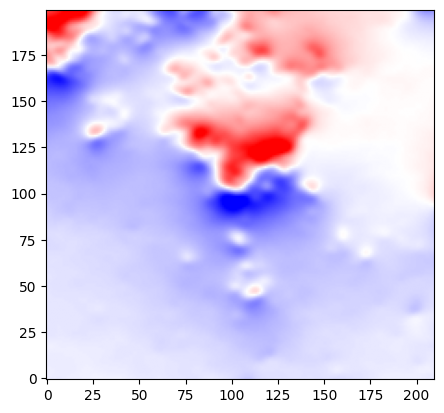

In [30]:
with plt.style.context("default"):
    fig, ax = plt.subplots()
    ax.imshow(b_hplt[:,:,1].T, origin="lower", cmap="bwr",
    vmin=-200, vmax=200)

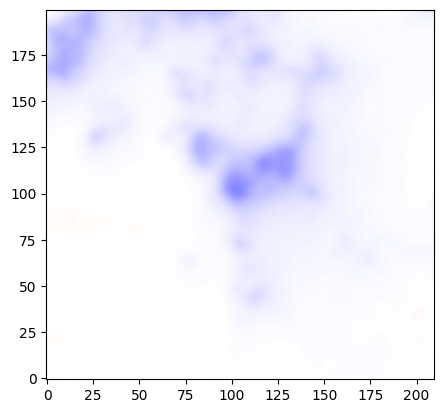

In [18]:
with plt.style.context("default"):
    fig, ax = plt.subplots()
    ax.imshow(b_hpr[:,:,-1].T, origin="lower", cmap="bwr",
    vmin=-1000, vmax=1000)

In [28]:
ImageBlinker(-b_hpr[:,:,0].T, sotsp_br_map_crop.data, norm1=ImageNormalize(vmin=-1500, vmax=1500),
            norm2=ImageNormalize(vmin=-1500, vmax=1500), cmap1="hmimag", cmap2="hmimag")

2026-04-29 14:16:53 - matplotlib.animation - INFO: Animation.save using <class 'matplotlib.animation.HTMLWriter'>


In [23]:
sotsp_br_wcs_mod = deepcopy(sotsp_br_map_crop.wcs)
sotsp_br_wcs_mod.wcs.aux.rsun_ref = sotsp_br_wcs_mod.wcs.aux.rsun_ref + 4*0.23712652199468398e6

In [24]:
b_hpln_map_in_hgs = sunpy.map.Map(
    b_hpln[:,:,1].T,
    sotsp_br_wcs_mod
)

b_hplt_map_in_hgs = sunpy.map.Map(
    b_hplt[:,:,1].T,
    sotsp_br_wcs_mod
)

In [25]:
dkist_rebin_wcs_mod = deepcopy(dkist_vbi_target_cube_crop_rebin.wcs)
dkist_rebin_wcs_mod = unwrap_wcs_to_fitswcs(dkist_rebin_wcs_mod)[0]
dkist_rebin_wcs_mod.wcs.aux.rsun_ref = sotsp_br_wcs_mod.wcs.aux.rsun_ref

In [26]:
with propagate_with_solar_surface():
    b_hpln_map_in_hp = b_hpln_map_in_hgs.reproject_to(
        dkist_rebin_wcs_mod
    )

    b_hplt_map_in_hp = b_hplt_map_in_hgs.reproject_to(
        dkist_rebin_wcs_mod
    )

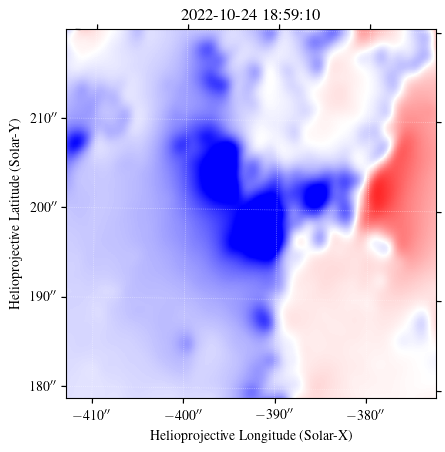

In [33]:
b_hpln_map_in_hp.plot(cmap="bwr", vmin=-200, vmax=200)

In [34]:
b_hpln_map_in_hp_norm = b_hpln_map_in_hp.data/np.sqrt(b_hpln_map_in_hp.data**2 + b_hplt_map_in_hp.data**2)
b_hplt_map_in_hp_norm = b_hplt_map_in_hp.data/np.sqrt(b_hpln_map_in_hp.data**2 + b_hplt_map_in_hp.data**2)

In [36]:
b_hpln_map_in_hp_norm.shape

(480, 480)

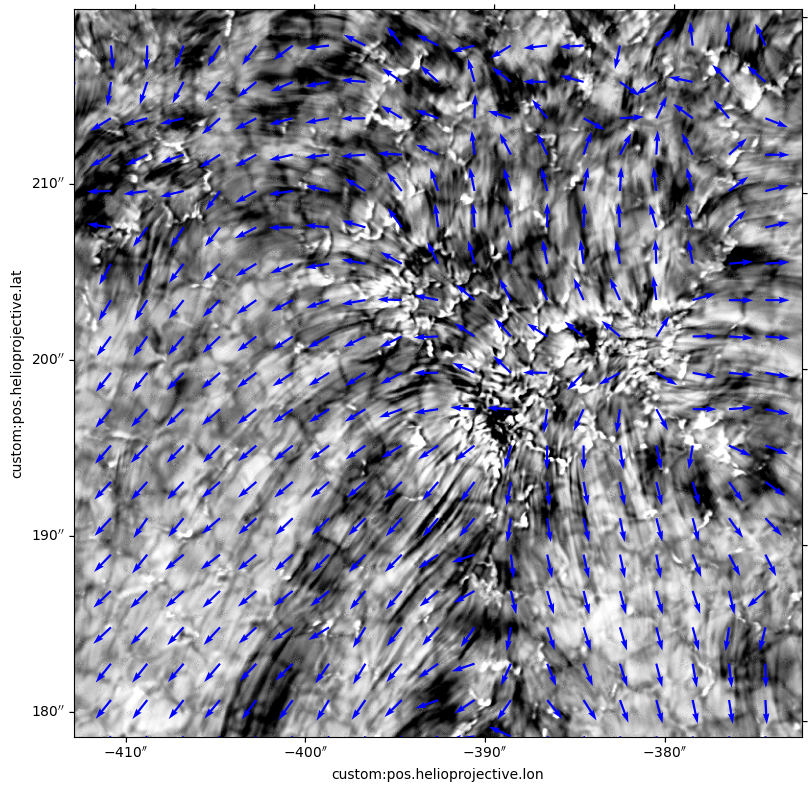

In [41]:
with plt.style.context('default'):
    fig = plt.figure(figsize=(8,8), layout="constrained")

    optimal_time = Time("2022-10-24T19:11:13")
    hbeta_index = np.argmin(np.abs(Hbeta_date_obs - optimal_time))
    ax = fig.add_subplot(projection=dkist_vbi_target_cube_crop.wcs)
    ax.imshow(Hbeta_pr_da[hbeta_index,:,:], origin="lower", cmap="Greys_r",
              norm=ImageNormalize(vmin=0,vmax=1),
              interpolation="none")
    ny, nx = b_hpln_map_in_hp_norm.shape
    yy, xx = np.mgrid[:ny, :nx]

    ax.quiver(xx[::24,::24]*8, yy[::24,::24]*8,
              b_hpln_map_in_hp_norm[::24,::24],
              b_hplt_map_in_hp_norm[::24,::24],
              angles='xy',
              scale_units='width', scale=30, color='b')